# 01 — Exploratory Data Analysis
Synthetic ICU Mortality Prediction (24-hour dataset)

This notebook explores the synthetic 24h ICU dataset: structure, missingness,
distributions of clinical variables, topic-feature distributions, and the
class balance of the five mortality outcomes.

**Reminder:** this is fully synthetic data, not real MIMIC-III patient data.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import load_data, CLINICAL_FEATURES, TOPIC_FEATURES, OUTCOME_COLS

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

df = load_data('../data/synthetic_icu_24h.csv')
df.shape

(27809, 28)

## Basic structure

In [2]:
df.head()

,patient_id,x1_gcs,x2_heart_rate,x3_sbp,x4_temp_c,x5_bun,x6_wbc,x7_potassium,x8_sodium,x9_bicarbonate,x10_admission_type,x11_gender,x12_age,topicB_hydroperitoneum,topicB_urinary_retention,topicB_newborn_resp_distress,topicB_coronary_artery_disease,topicB_pneumothorax_effusion,topicB_nursing_assessment,topicB_endotracheal_intubation,topicB_sepsis,topicB_medical_assessment,topicB_spinal_hematoma,mortality_in_hospital,mortality_48h,mortality_72h,mortality_30day,mortality_1year
0,1,14,71.3,146.0,36.82,13.7,6.72,4.19,145.0,22.7,0,0,47.4,0.001915,0.091858,0.136681,0.333894,0.009137,0.009968,0.043344,3.408173e-04,0.177306,0.195555,0,0,0,0,0
1,2,10,63.6,100.9,35.69,52.2,10.68,3.95,132.9,30.4,2,1,44.9,0.068733,0.194343,0.119330,0.006114,0.073993,0.175384,0.232752,2.337683e-03,0.125508,0.001506,0,0,0,0,0
2,3,15,105.3,114.7,35.30,24.6,11.70,4.14,144.9,21.6,0,0,67.0,0.000154,0.166309,0.053874,0.008781,0.045551,0.219679,0.252532,4.647230e-03,0.157713,0.090760,0,0,0,0,0
3,4,15,83.3,91.2,37.65,30.6,8.23,2.85,143.5,27.3,2,1,59.1,0.048250,0.183937,0.012540,0.005720,0.004788,0.002606,0.035030,2.486036e-01,0.443444,0.015082,0,0,0,0,0
4,5,8,119.1,91.8,38.45,7.5,3.47,4.94,132.0,28.9,2,1,51.6,0.110071,0.310797,0.295817,0.010603,0.068997,0.001339,0.047750,8.198697e-07,0.151908,0.002718,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27809 entries, 0 to 27808
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      27809 non-null  int64  
 1   x1_gcs                          27809 non-null  int64  
 2   x2_heart_rate                   27809 non-null  float64
 3   x3_sbp                          27809 non-null  float64
 4   x4_temp_c                       27809 non-null  float64
 5   x5_bun                          27809 non-null  float64
 6   x6_wbc                          27809 non-null  float64
 7   x7_potassium                    27809 non-null  float64
 8   x8_sodium                       27809 non-null  float64
 9   x9_bicarbonate                  27809 non-null  float64
 10  x10_admission_type              27809 non-null  int64  
 11  x11_gender                      27809 non-null  int64  
 12  x12_age                         27809 non-n

In [4]:
# Missing values check
missing = df.isnull().sum()
missing[missing > 0] if missing.sum() > 0 else print("No missing values (as expected — synthetic data).")

No missing values (as expected — synthetic data).


## Descriptive statistics — clinical variables

In [5]:
df[CLINICAL_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
x1_gcs,27809.0,12.720091,2.073980,3.00,11.00,13.00,15.00,15.00
x2_heart_rate,27809.0,87.800277,17.923298,40.00,75.80,87.70,99.80,178.10
x3_sbp,27809.0,121.922838,22.114895,60.00,107.00,121.70,136.80,214.10
x4_temp_c,27809.0,36.990742,0.802678,33.94,36.45,36.99,37.53,40.61
x5_bun,27809.0,23.984588,13.932523,2.00,13.80,21.30,31.50,119.40
x6_wbc,27809.0,10.803315,5.379480,0.50,6.85,9.96,13.80,49.67
x7_potassium,27809.0,4.102348,0.597335,2.00,3.70,4.11,4.50,6.55
x8_sodium,27809.0,138.015056,4.515118,120.40,135.00,138.00,141.10,157.00
x9_bicarbonate,27809.0,23.988755,4.492233,6.20,21.00,24.00,27.00,40.00
x10_admission_type,27809.0,1.665648,0.724916,0.00,2.00,2.00,2.00,2.00


## Class balance across the 5 mortality outcomes

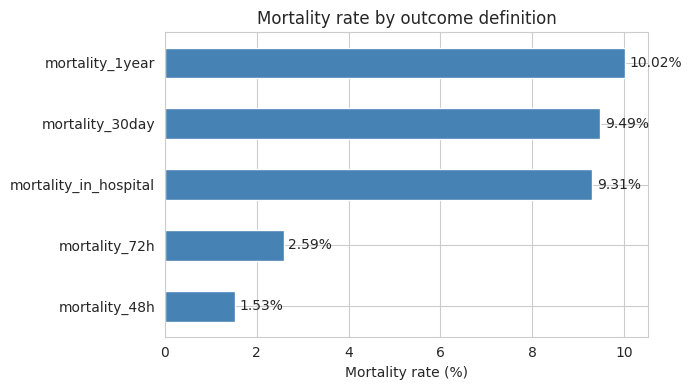

mortality_48h             1.528282
mortality_72h             2.585494
mortality_in_hospital     9.309936
mortality_30day           9.486138
mortality_1year          10.021935
dtype: float64

In [6]:
outcome_rates = df[OUTCOME_COLS].mean() * 100
outcome_rates = outcome_rates.sort_values()

fig, ax = plt.subplots(figsize=(7,4))
outcome_rates.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Mortality rate (%)')
ax.set_title('Mortality rate by outcome definition')
for i, v in enumerate(outcome_rates):
    ax.text(v + 0.1, i, f'{v:.2f}%', va='center')
plt.tight_layout()
plt.savefig('../results/figures/eda_outcome_rates.png', dpi=150)
plt.show()

outcome_rates

All five outcomes are imbalanced (roughly 1.5%–10% positive), which is why
the modeling notebooks use SMOTE + metrics like PR-AUC and F1 rather than
relying on raw accuracy.

## Distributions of clinical variables, split by in-hospital mortality

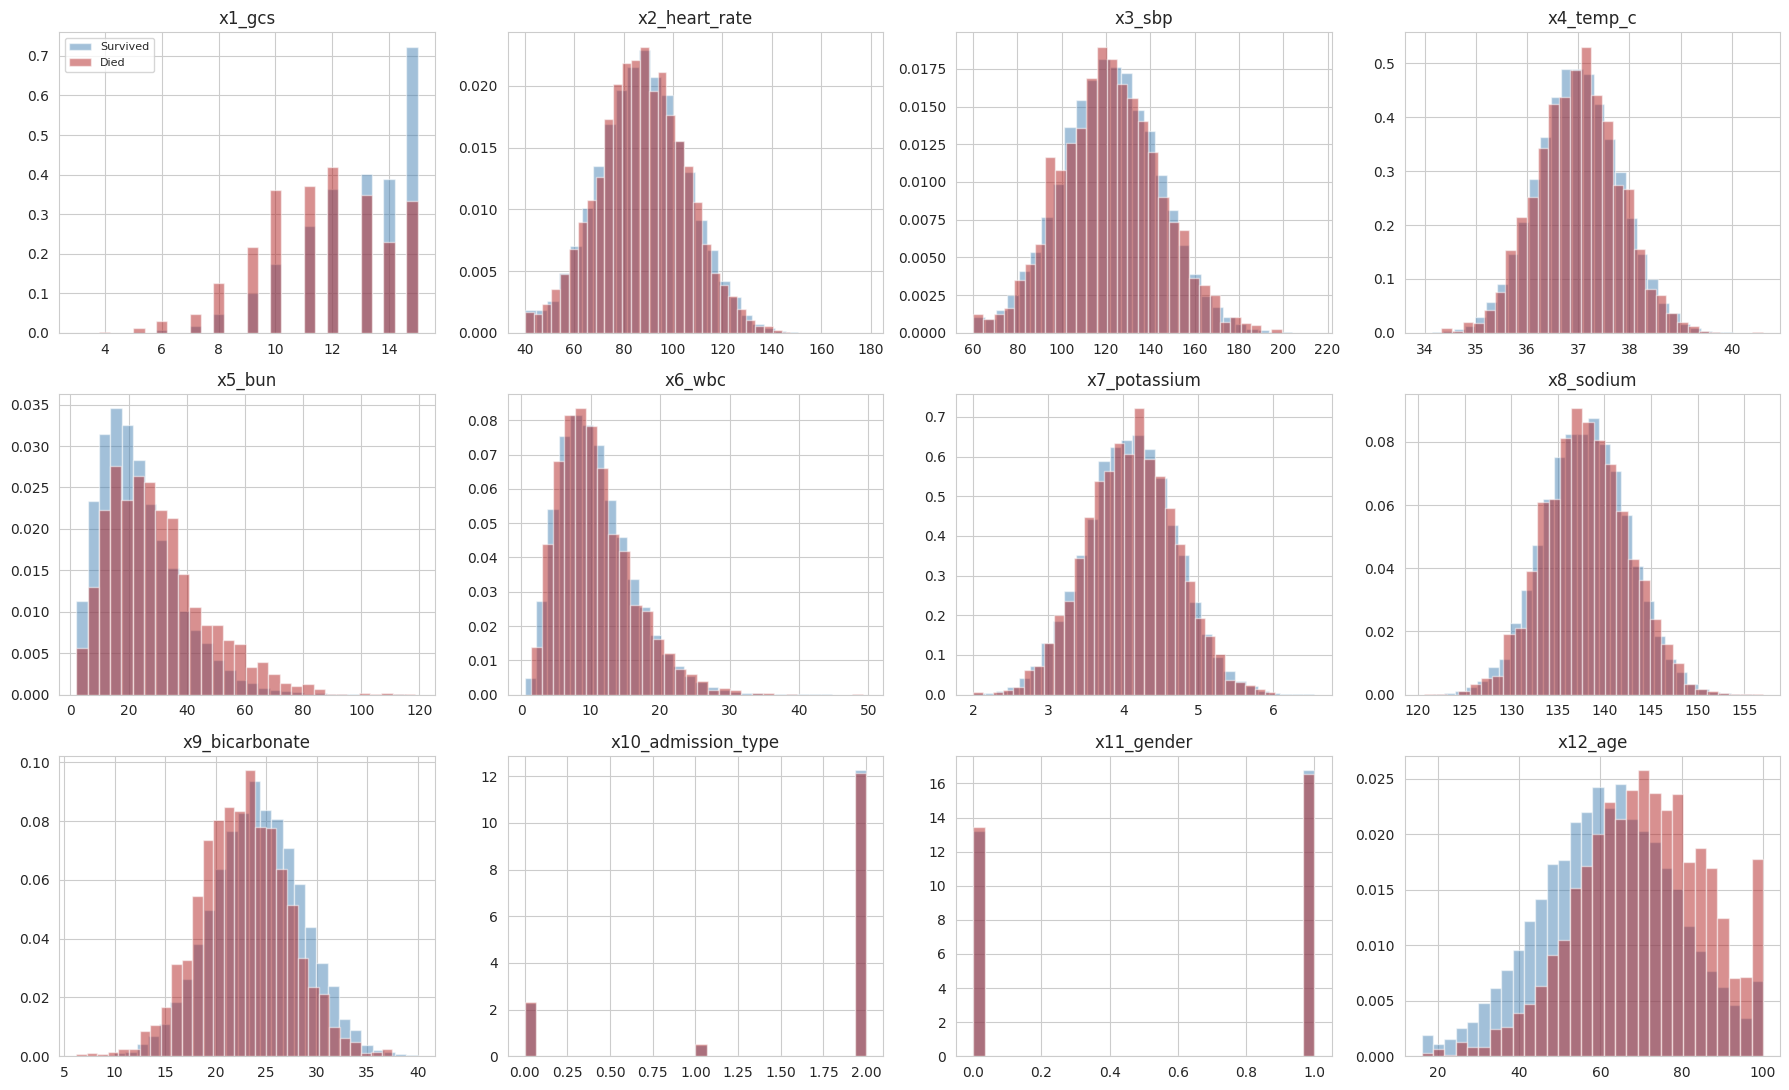

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.ravel()
for i, col in enumerate(CLINICAL_FEATURES):
    for label, color in [(0, 'steelblue'), (1, 'firebrick')]:
        subset = df[df['mortality_in_hospital'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.5, density=True, color=color,
                     label='Survived' if label == 0 else 'Died')
    axes[i].set_title(col)
    if i == 0:
        axes[i].legend(fontsize=8)
plt.tight_layout()
plt.savefig('../results/figures/eda_clinical_distributions.png', dpi=150)
plt.show()

Notice GCS (`x1_gcs`), BUN (`x5_bun`), bicarbonate (`x9_bicarbonate`), and
age (`x12_age`) show the clearest separation between survivors and non-survivors
— consistent with what the original paper (and our data-generating design)
flags as the most clinically important predictors.

## Correlation matrix — clinical variables

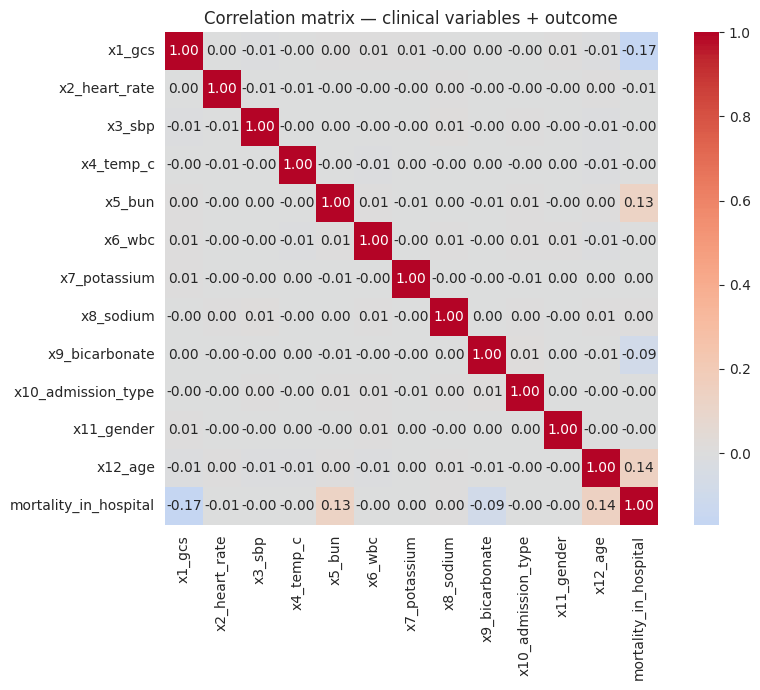

In [8]:
corr = df[CLINICAL_FEATURES + ['mortality_in_hospital']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation matrix — clinical variables + outcome')
plt.tight_layout()
plt.savefig('../results/figures/eda_correlation_matrix.png', dpi=150)
plt.show()

## Topic feature distributions

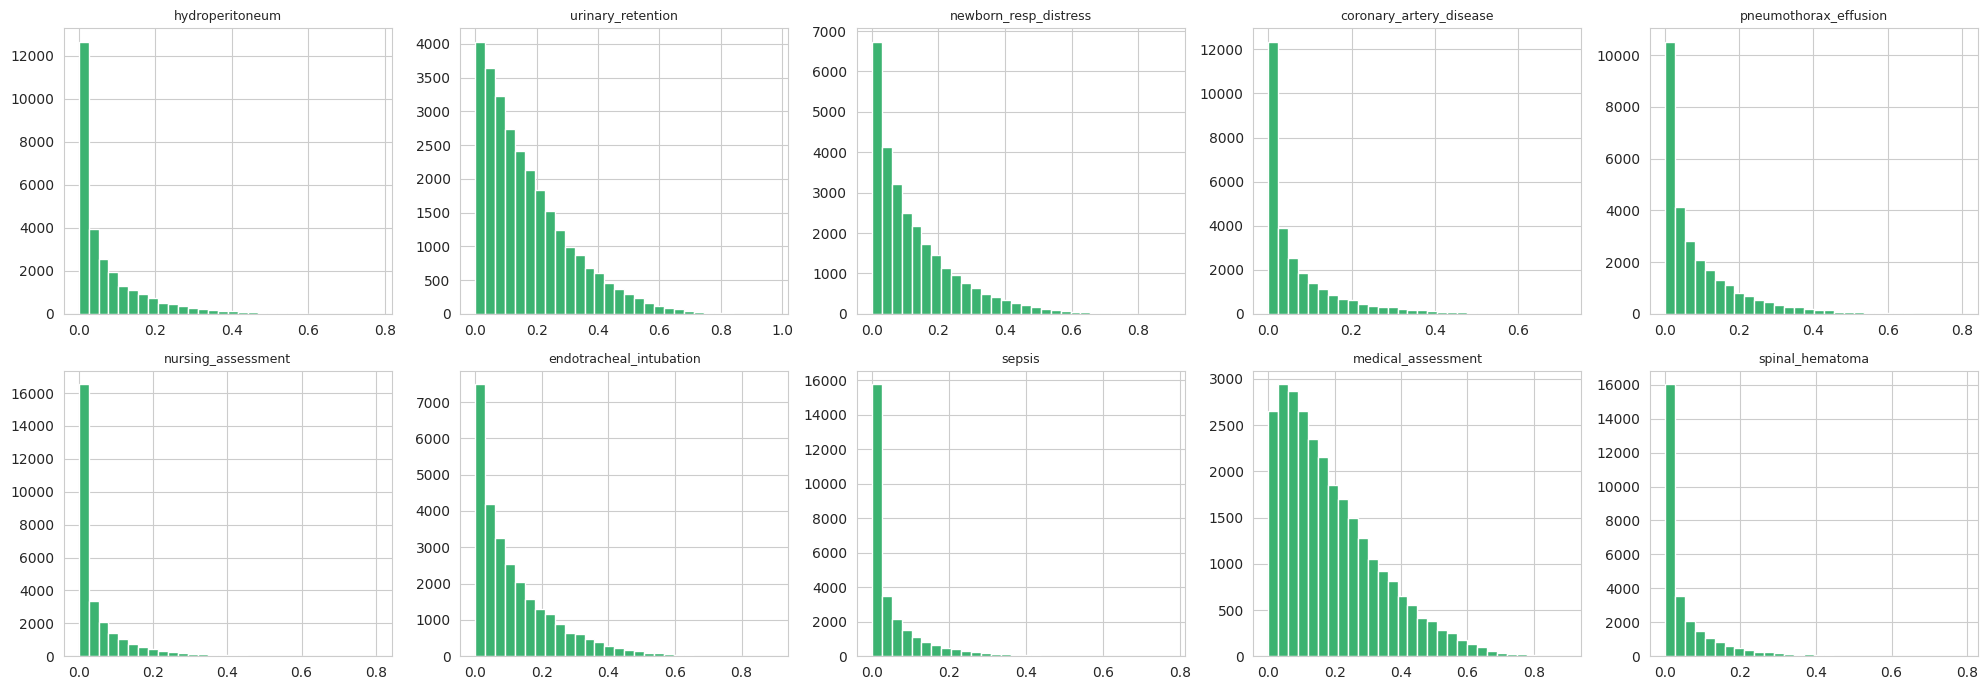

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.ravel()
for i, col in enumerate(TOPIC_FEATURES):
    axes[i].hist(df[col], bins=30, color='mediumseagreen')
    axes[i].set_title(col.replace('topicB_', ''), fontsize=9)
plt.tight_layout()
plt.savefig('../results/figures/eda_topic_distributions.png', dpi=150)
plt.show()

Each patient's 10 topic scores are drawn from a Dirichlet distribution, so
they sum to 1 per row (like real LDA document-topic distributions) — that's
why each topic's marginal distribution is right-skewed toward 0.

## Summary of EDA findings

- No missing data (synthetic dataset, generated complete).
- All 5 mortality outcomes are imbalanced — in-hospital ~9%, 48h ~1.5%,
  72h ~2.6%, 30-day ~9.5%, 1-year ~10%.
- Clinical variables `x1_gcs`, `x5_bun`, `x9_bicarbonate`, and `x12_age` show
  visible separation between survivors and non-survivors.
- Topic features are Dirichlet-distributed probability scores (sum to 1 per patient).

Next: `02_preprocessing.ipynb` builds the train/test split, feature-set
experiments, and SMOTE-balanced training data used by the modeling notebooks.